# Phase 4 — Decision Engine Analysis & Validation

End-to-end walkthrough of the RoadSage Phase 4 decision pipeline:

| Module | File |
|---|---|
| Shared types | `app/decision/__init__.py` |
| Geometric logic | `app/decision/geometric_logic.py` |
| Safety gate | `app/decision/safety_gate.py` |
| Confidence fusion | `app/decision/confidence_fusion.py` |
| ML fallback | `app/decision/ml_fallback.py` |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from app.decision import DriveCommand, DecisionPath, DecisionResult, TemporalBuffer
from app.decision.geometric_logic import (
    GeometricConfig, compute_geometric_decision, compute_geometric_signal_strength
)
from app.decision.safety_gate import SafetyGate, SafetyGateResult, is_stop_always_immediate
from app.decision.confidence_fusion import ConfidenceFusion, FusionConfig
from app.decision.ml_fallback import MLFallbackModel
from app.lane_detection.lane_geometry import LaneGeometry
from app.scene_understanding import SceneContext

import os
os.makedirs("outputs", exist_ok=True)

print("All Phase 4 imports OK ✓")

All Phase 4 imports OK ✓


## Decision Priority Chain Walkthrough

Five priority levels, each demonstrated with a concrete scenario.

In [2]:
geo_config = GeometricConfig.from_yaml("../configs/decision_engine.yaml")
gate = SafetyGate("../configs/decision_engine.yaml")
fusion = ConfidenceFusion("../configs/decision_engine.yaml")
ml = MLFallbackModel("../configs/decision_engine.yaml")

print("=" * 60)
print("DECISION PRIORITY CHAIN — 5 SCENARIOS")
print("=" * 60)

# Helper
def make_geom(offset, curvature, left=True, right=True, valid=True):
    return LaneGeometry(
        offset=offset, curvature=curvature,
        offset_m=offset, curvature_inv_m=curvature,
        left_lane_detected=left, right_lane_detected=right,
        left_lane_confidence=0.90 if left else 0.0,
        right_lane_confidence=0.90 if right else 0.0,
        lane_geometry_valid=valid and (left or right),
    )

# --- Priority 1: Safety Gate — immediate hazard ---
print("\n[Priority 1] Safety Gate — immediate hazard")
hazard_scene = SceneContext(immediate_hazard=True, hazard_reason="pedestrian in path")
proposed_p1 = DecisionResult(DriveCommand.FORWARD, 0.88, DecisionPath.GEOMETRIC)
result_p1 = gate.evaluate(hazard_scene, proposed_p1)
print(f"  Input     : FORWARD (conf=0.88), hazard=True")
print(f"  Output    : {result_p1.describe()}")

# --- Priority 2: Geometric — both lanes, clear offset ---
print("\n[Priority 2] Geometric — both lanes, positive offset (drift right → steer left)")
clear_scene = SceneContext()
geom_p2 = make_geom(offset=+0.42, curvature=0.001)
result_p2_raw = compute_geometric_decision(geom_p2, clear_scene, geo_config)
result_p2 = gate.evaluate(clear_scene, result_p2_raw)
print(f"  Geometry  : offset=+0.42m, curvature=0.001m⁻¹")
print(f"  Output    : {result_p2.describe()}")

# --- Priority 3: Single-lane fallback ---
print("\n[Priority 3] Single-lane fallback — only right lane visible")
geom_p3 = make_geom(offset=0.0, curvature=0.0, left=False, right=True)
result_p3_raw = compute_geometric_decision(geom_p3, clear_scene, geo_config)
result_p3 = gate.evaluate(clear_scene, result_p3_raw)
print(f"  Geometry  : no left lane detected")
print(f"  Output    : {result_p3.describe()}")

# --- Priority 4: ML fallback ---
print(f"\n[Priority 4] ML Fallback — model loaded: {ml.is_ready()}")
if ml.is_ready():
    import cv2, glob
    imgs = sorted(glob.glob("../rgb/rgb_image_*.png"))
    if imgs:
        img = cv2.imread(imgs[0])
        result_p4 = ml.predict_to_decision_result(img, use_mc_dropout=True)
        print(f"  Output    : {result_p4.describe()}")
else:
    print("  (models/decision_cnn.onnx not found — run training pipeline first)")
    result_p4 = DecisionResult(DriveCommand.STOP, 0.0, DecisionPath.ML_FALLBACK)
    print(f"  Placeholder: {result_p4.describe()}")

# --- Priority 5: Confidence gate ---
print("\n[Priority 5] Confidence gate — ML uncertainty too high")
low_conf = DecisionResult(DriveCommand.LEFT, 0.42, DecisionPath.ML_FALLBACK)
result_p5 = gate.evaluate_confidence_gate(low_conf)
print(f"  Input     : LEFT (conf=0.42)")
print(f"  Output    : {result_p5.describe()}")

print("\n" + "=" * 60)

ML fallback model not found at 'models/decision_cnn.onnx'. Run training/trainers/train_decision.py to generate weights.
SAFETY GATE TRIGGERED: pedestrian in path
Confidence gate triggered: conf=0.42 < 0.60


DECISION PRIORITY CHAIN — 5 SCENARIOS

[Priority 1] Safety Gate — immediate hazard
  Input     : FORWARD (conf=0.88), hazard=True
  Output    : STOP (conf=1.00) via safety_gate | offset=+0.00m | curvature=0.0000 | ⚠ pedestrian in path

[Priority 2] Geometric — both lanes, positive offset (drift right → steer left)
  Geometry  : offset=+0.42m, curvature=0.001m⁻¹
  Output    : LEFT (conf=0.90) via geometric | offset=+0.42m | curvature=0.0010

[Priority 3] Single-lane fallback — only right lane visible
  Geometry  : no left lane detected
  Output    : RIGHT (conf=0.60) via single_lane | offset=+0.00m | curvature=0.0000

[Priority 4] ML Fallback — model loaded: False
  (models/decision_cnn.onnx not found — run training pipeline first)
  Placeholder: STOP (conf=0.00) via ml_fallback | offset=+0.00m | curvature=0.0000

[Priority 5] Confidence gate — ML uncertainty too high
  Input     : LEFT (conf=0.42)
  Output    : STOP (conf=0.42) via confidence_gate | offset=+0.00m | curvature=0.0000 | ⚠

## Temporal Buffer Behavior

Simulate 20 frames of lane detections with one noisy STOP frame injected at frame 10.
Shows how the temporal buffer prevents a single bad frame from triggering a full STOP.

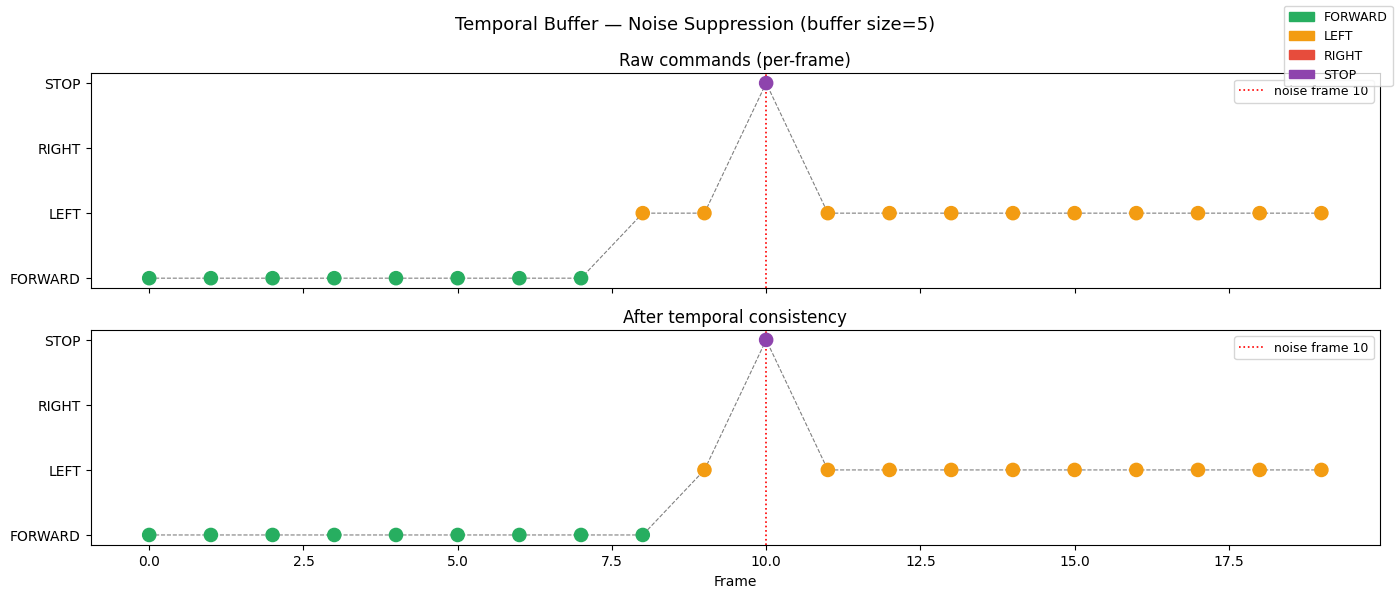

Saved: outputs/04_temporal_buffer.png


In [4]:
from app.decision.geometric_logic import apply_temporal_consistency

# apply_temporal_consistency expects a plain dict, not a GeometricConfig
temporal_cfg = {"temporal_consistency_frames": 5}

buf = TemporalBuffer(maxlen=5)
n_frames = 20

raw_commands    = []
smooth_commands = []

for i in range(n_frames):
    # Frames 0-7: FORWARD scenario (small positive offset)
    if i < 8:
        geom = make_geom(offset=0.08, curvature=0.002)
        raw = compute_geometric_decision(geom, SceneContext(), geo_config) or \
              DecisionResult(DriveCommand.FORWARD, 0.80, DecisionPath.GEOMETRIC)
    # Frame 10: single noisy STOP (low confidence)
    elif i == 10:
        raw = DecisionResult(DriveCommand.STOP, 0.55, DecisionPath.GEOMETRIC,
                              offset_m=0.08, curvature_inv_m=0.002)
    # Frames 8-9, 11-19: LEFT scenario (large positive offset → steer left)
    else:
        geom = make_geom(offset=+0.42, curvature=0.001)
        raw = compute_geometric_decision(geom, SceneContext(), geo_config) or \
              DecisionResult(DriveCommand.LEFT, 0.82, DecisionPath.GEOMETRIC)

    smoothed = apply_temporal_consistency(raw, buf, temporal_cfg)
    buf.push(raw)

    raw_commands.append(raw.command.value)
    smooth_commands.append(smoothed.command.value)

CMD_INT    = {"FORWARD": 0, "LEFT": 1, "RIGHT": 2, "STOP": 3}
CMD_COLOUR = {"FORWARD": "#27ae60", "LEFT": "#f39c12", "RIGHT": "#e74c3c", "STOP": "#8e44ad"}

frames      = list(range(n_frames))
raw_ints    = [CMD_INT[c] for c in raw_commands]
smooth_ints = [CMD_INT[c] for c in smooth_commands]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("Temporal Buffer — Noise Suppression (buffer size=5)", fontsize=13)

for ax, ints, cmds, title in [
    (ax1, raw_ints,    raw_commands,    "Raw commands (per-frame)"),
    (ax2, smooth_ints, smooth_commands, "After temporal consistency"),
]:
    ax.scatter(frames, ints, c=[CMD_COLOUR[c] for c in cmds], s=90, zorder=3)
    ax.plot(frames, ints, color="grey", linewidth=0.8, linestyle="--")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["FORWARD", "LEFT", "RIGHT", "STOP"])
    ax.set_title(title)
    ax.axvline(10, color="red", linewidth=1.2, linestyle=":", label="noise frame 10")
    ax.legend(fontsize=9)

ax2.set_xlabel("Frame")
patches = [mpatches.Patch(color=v, label=k) for k, v in CMD_COLOUR.items()]
fig.legend(handles=patches, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/04_temporal_buffer.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: outputs/04_temporal_buffer.png")

## Phase 4 Exit Criteria Checklist

Automated validation of all Phase 4 completion criteria.

In [6]:
results = {}

# --- 1. Geometric logic: 5 representative test cases ---
test_geom_cases = [
    (make_geom(0.05,  0.001),  DriveCommand.FORWARD),
    (make_geom(+0.4,  0.001),  DriveCommand.LEFT),
    (make_geom(-0.4,  0.001),  DriveCommand.RIGHT),
    (make_geom(0.05, +0.008),  DriveCommand.RIGHT),
    (make_geom(0.05, -0.008),  DriveCommand.LEFT),
]
geo_pass = all(
    compute_geometric_decision(g, SceneContext(), geo_config) is not None and
    compute_geometric_decision(g, SceneContext(), geo_config).command == expected
    for g, expected in test_geom_cases
)
results["Geometric logic (5 representative cases)"] = geo_pass

# --- 2. Safety gate: 3 hazard scenarios trigger STOP ---
hazard_cases = [
    SceneContext(immediate_hazard=True, hazard_reason="pedestrian"),
    SceneContext(immediate_hazard=True, hazard_reason="vehicle"),
    SceneContext(immediate_hazard=True, hazard_reason="obstacle"),
]
proposed_fwd = DecisionResult(DriveCommand.FORWARD, 0.88, DecisionPath.GEOMETRIC)
safety_pass = all(
    gate.evaluate(s, proposed_fwd).command == DriveCommand.STOP
    for s in hazard_cases
)
results["Safety gate triggers STOP on every hazard (3 scenarios)"] = safety_pass

# --- 3. Temporal buffer: non-STOP noise is suppressed
#     Design: STOP is *never* suppressed (safety-critical).
#     Verified here: a single noisy LEFT amid 5× FORWARD is overridden → FORWARD
buf_test = TemporalBuffer(maxlen=5)
for _ in range(5):
    buf_test.push(DecisionResult(DriveCommand.FORWARD, 0.85, DecisionPath.GEOMETRIC))
noisy_left = DecisionResult(DriveCommand.LEFT, 0.55, DecisionPath.GEOMETRIC,
                             offset_m=0.0, curvature_inv_m=0.0)
smoothed_test = apply_temporal_consistency(noisy_left, buf_test, {"temporal_consistency_frames": 5})
results["Temporal buffer suppresses single non-STOP noise frame"] = (
    smoothed_test.command == DriveCommand.FORWARD
)

# --- 4. Confidence fusion produces sensible values ---
fusion_cfg = FusionConfig()
from app.decision.confidence_fusion import fuse_confidence
test_inputs = [
    (0.90, 0.85, 0.80),
    (0.40, 0.40, 0.30),
    (0.90, 0.0,  0.0),
    (0.0,  0.0,  0.90),
]
fusion_pass = all(
    0.0 <= fuse_confidence(l, g, m, fusion_cfg).final_confidence <= 1.0
    for l, g, m in test_inputs
)
results["Confidence fusion in [0,1] for all test inputs"] = fusion_pass

# --- 5. Pseudo-label file ---
labels_path = Path("../data/mnnit/pseudo_labels/labels.jsonl")
results["Pseudo-label file exists and non-empty (needs pipeline run)"] = (
    labels_path.exists() and labels_path.stat().st_size > 0
)

# --- 6. ML fallback model ---
results["Decision CNN ONNX ready (needs training run)"] = ml.is_ready()

# --- 7. is_stop_always_immediate ---
results["is_stop_always_immediate() returns True"] = is_stop_always_immediate()

# --- Print ---
print("=" * 60)
print("  PHASE 4 EXIT CRITERIA CHECKLIST")
print("=" * 60)
all_pass = True
for criterion, passed in results.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {criterion}")
    if not passed:
        all_pass = False
print("=" * 60)
if all_pass:
    print("  🎉  ALL CRITERIA MET — Phase 4 complete!")
else:
    n_fail = sum(1 for v in results.values() if not v)
    print(f"  ⚠   {n_fail} item(s) need action before Phase 4 is fully done")
print("=" * 60)

SAFETY GATE TRIGGERED: pedestrian
SAFETY GATE TRIGGERED: vehicle
SAFETY GATE TRIGGERED: obstacle


  PHASE 4 EXIT CRITERIA CHECKLIST
  ✅  Geometric logic (5 representative cases)
  ✅  Safety gate triggers STOP on every hazard (3 scenarios)
  ✅  Temporal buffer suppresses single non-STOP noise frame
  ✅  Confidence fusion in [0,1] for all test inputs
  ❌  Pseudo-label file exists and non-empty (needs pipeline run)
  ❌  Decision CNN ONNX ready (needs training run)
  ✅  is_stop_always_immediate() returns True
  ⚠   2 item(s) need action before Phase 4 is fully done
